# 

In [5]:
if 0:
    print("hola")

/home/anibal/microlensing/simulation_Rubin/roman_rubin


  0%|                                                     | 0/1 [00:00<?, ?it/s]

mag_base 14.4178


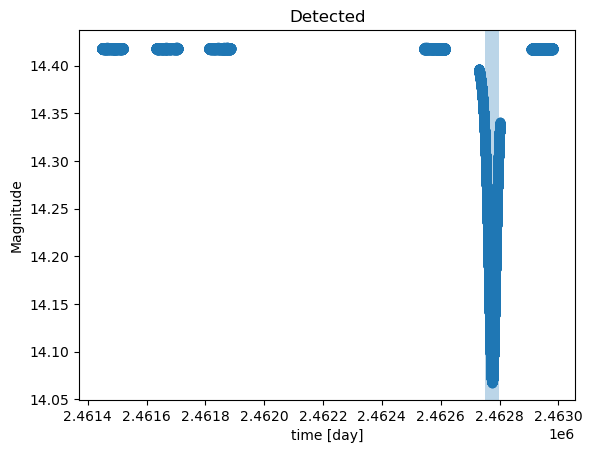

100%|█████████████████████████████████████████████| 1/1 [00:01<00:00,  1.23s/it]


In [6]:
import h5py
import pandas as pd
import numpy as np
import os,sys
import matplotlib.pyplot as plt
from astropy import units as u
sys.path.append('/home/anibal/microlensing/simulation_Rubin/roman_rubin/')
from class_analysis import Analysis_Event
from Sim_Fit_Event import simulation_event, mag
from ulens_params import microlensing_params
current_path = '/home/anibal/microlensing/simulation_Rubin/roman_rubin/'
path_ephemerides= current_path+'/ephemerides/Roman_positions.npy'
path_dataslice = current_path+'/opsims/baseline/dataSlice.npy'
script_dir = '/home/anibal/microlensing/simulation_Rubin/roman_rubin/'

from astropy.table import QTable
from scipy.interpolate import interp1d

def add_noise(pyLIMA_telescope, event):
    """
    Add magnitude noise to CS or ODI light curve.
    """

    m = np.array([9,10,11,12,13,14,15,16,17,18,19,20,21,22,23])

    S_N = {
        "ODI": np.array([5228.1,3298.5,2080.8,1312.3,827.1,520.4,326.1,202.2,122.5,70.7,37.5,18,7.9,3.3,1.3]),
        "CS":  np.array([908.5,573,361.2,227.4,142.6,88.7,54.1,31.6,17.1,8.4,3.7,1.6,0.6,0.3,0.1])
    }

    
    # S_N_CS=np.array([908.5,573,361.2,227.4,142.6,88.7,54.1,31.6,17.1,8.4,3.7,1.6,0.6,0.3,0.1])
    # S_N_ODI=np.array([5228.1,3298.5,2080.8,1312.3,827.1,520.4,326.1,202.2,122.5,70.7,37.5,18,7.9,3.3,1.3])

    telescope_name = event.name
    ZP = event.ZP_dict
    #ZP = {'W149': 27.615, 'CS': 27.03, 'ODI': 27.615}

    if telescope_name not in S_N:
        raise ValueError("telescope_name debe ser 'ODI' o 'CS'")

    SN_interp_log = interp1d(
        m,
        np.log10(S_N[telescope_name]),
        kind="linear",
        bounds_error=True
    )

    def delta_m(Signal_to_noise):
        return (2.5 / np.log(10)) / Signal_to_noise

    def SN(mag_value):
        return 10**SN_interp_log(mag_value)

    def sigma_m(mag_value):
        return delta_m(SN(mag_value))

    X = pyLIMA_telescope.lightcurve["time"].value
    flux = pyLIMA_telescope.lightcurve["flux"].value

    ym = mag(ZP[telescope_name], flux)

    err_mag = sigma_m(ym)

    mag_noisy = np.random.normal(
        loc=ym,
        scale=err_mag
    )

    data_tbl = QTable(
        [
            pyLIMA_telescope.lightcurve["err_flux"].value,
            err_mag,
            flux,
            pyLIMA_telescope.lightcurve["inv_err_flux"].value,
            mag_noisy,
            X,
        ],
        names=(
            "err_flux",
            "err_mag",
            "flux",
            "inv_err_flux",
            "mag",
            "time",
        ),
    )
    pyLIMA_telescope.lightcurve = data_tbl

    return pyLIMA_telescope


def odi_run(i,path_TRILEGAL_set, path_GENULENS_set, savepath,  path_ephemerides, path_dataslice, rho, telescope_name):
    ra, dec= 267.92497054815516, -29.152232510353276
    system_type = 'lenses_low_mass'
    model = 'FSPL'
    orbital_period = 0
    ZP = {'W149': 27.615, 'CS': 27.03, 'ODI': 27.615}
    mag_lim_dict = {'W149': 27.6, 'CS': 18.65, 'ODI': 21.54}
    ROW = i-10000*int(i/10000)
    seed = i
    mag_lim=18.65
    data_trilegal = pd.read_csv(path_TRILEGAL_set)
    data_trilegal = data_trilegal[data_trilegal["g"]<mag_lim]
    TRILEGAL_row = data_trilegal.iloc[ROW+1]
    TRILEGAL_row.columns = pd.read_csv(path_TRILEGAL_set, nrows=0).columns
    # print(TRILEGAL_row)
    GENULENS_row = pd.read_csv(path_GENULENS_set, skiprows=ROW+1, nrows=1, header=None)
    GENULENS_row.columns = pd.read_csv(path_GENULENS_set, nrows=0).columns
    
    event = simulation_event(ra, dec, 69, path_ephemerides, path_dataslice,
                        TRILEGAL_row, GENULENS_row.iloc[0], system_type, model, 0, telescope_name, ZP)
    params = event.event_param()
    # print("Event name", event.name)
    if params['rho']>99:
        print("rho>99 source too large")
        return 0,0,0,0
    delta_t = 2*params['tE']*np.sqrt((1 + params['rho'])**2 - params['u0']**2)
    # print(params['tE'],params['rho'],params['u0'], delta_t)
    tini,tfin = params['t0']-3.5*delta_t, params['t0']+3.5*delta_t
    timestamps = np.arange(tini, tfin, 20000/86400)
    if not event.name =="W149":
        event_pyLIMA = event.Event_Rubin_custom_cadence({'g':timestamps})
    else:
        event_pyLIMA = event.Event_roman_ODI()
    my_own_model2, pyLIMA_parameters = event.sim_clear_Rubin_lightcurves(event_pyLIMA, params)
    # print("Add noise")
    if not event.name =="W149":
        my_own_model2.event.telescopes[0] = add_noise(my_own_model2.event.telescopes[0], event)
    decision = event.deviation_from_constant(pyLIMA_parameters, my_own_model2.event.telescopes)
    # print("telescopes ", my_own_model2.event.telescopes[0].name)
    return my_own_model2, pyLIMA_parameters, TRILEGAL_row[my_own_model2.event.telescopes[0].name], decision
from tqdm import tqdm
for j in tqdm(range(1)):
    
    i=1
    # j=22
    path_TRILEGAL_set = f'/home/anibal/microlensing/simulation_Rubin/roman_rubin/chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_{i}.csv'
    path_GENULENS_set = f'/home/anibal/microlensing/simulation_Rubin/roman_rubin/chunks_TRILEGAL_GENULENS/Genulens_chunk_{i}.csv'
    my_own_model2, pyLIMA_parameters ,mag_base, decision = odi_run(j,path_TRILEGAL_set, path_GENULENS_set, False ,  "", "",0.01,"W149")
    # my_own_model2, pyLIMA_parameters ,mag_base = odi_run(j,path_TRILEGAL_set, path_GENULENS_set, False ,  "", "",0.4,"ODI")
    # my_own_model2, pyLIMA_parameters ,mag_base = odi_run(j,path_TRILEGAL_set, path_GENULENS_set, False ,  "", "",0.4,"W149")
    # print(pyLIMA_parameters)
    # print(decision)
    # if not int(decision):
        # print(j)
    if not my_own_model2==0:
        # print(pyLIMA_parameters)
        tel_lc = my_own_model2.event.telescopes[0].lightcurve
        # print(my_own_model2.event.telescopes[0].name)
        %matplotlib inline
        plt.close("all")
        plt.errorbar(tel_lc["time"], tel_lc["mag"],tel_lc["err_mag"], ls="",marker="o",capsize=3)
        plt.axvspan(pyLIMA_parameters["t0"]-25,pyLIMA_parameters["t0"]+25,alpha=0.3)
        print("mag_base",mag_base)
        # print("mag_base pyLIMA",mag(27.615,pyLIMA_parameters["ftotal_g"]))
        if decision:
            plt.title(f"Detected")
        else:
            plt.title(f"Not detected")
        # plt.axhline(mag_base)
        
        # plt.axvline(pyLIMA_parameters["t0"])
        plt.xlabel("time [day]")
        plt.ylabel("Magnitude")
        plt.show()

In [11]:
my_own_model2.event.telescopes[0].lightcurve

time,mag,err_mag,flux,err_flux,inv_err_flux
JD,,,,,
float64,float64,float64,float64,float64,float64
2461447.5,14.418011771945025,0.0003522768217382806,190018.24,61.65311736510977,0.016219780000385056
2461447.5104166665,14.417952120963086,0.00035225746797585536,190028.68,61.653117365194724,0.016219780000362706
2461447.520833333,14.417738912636715,0.0003521883012200302,190066.0,61.653117365279655,0.016219780000340363
2461447.5312499995,14.418318420572632,0.0003523763306811118,189964.58,61.65311736536461,0.016219780000318013
2461447.541666666,14.417621928643896,0.00035215035630030466,190086.48,61.65311736544955,0.016219780000295666
2461447.5520833326,14.417553846106976,0.00035212827493531226,190098.4,61.6531173655345,0.016219780000273316
2461447.562499999,14.418422904328601,0.0003524102425793775,189946.3,61.65311736561946,0.016219780000250966
2461447.5729166656,14.417543794013561,0.00035212501483506087,190100.16,61.653117365704404,0.01621978000022862


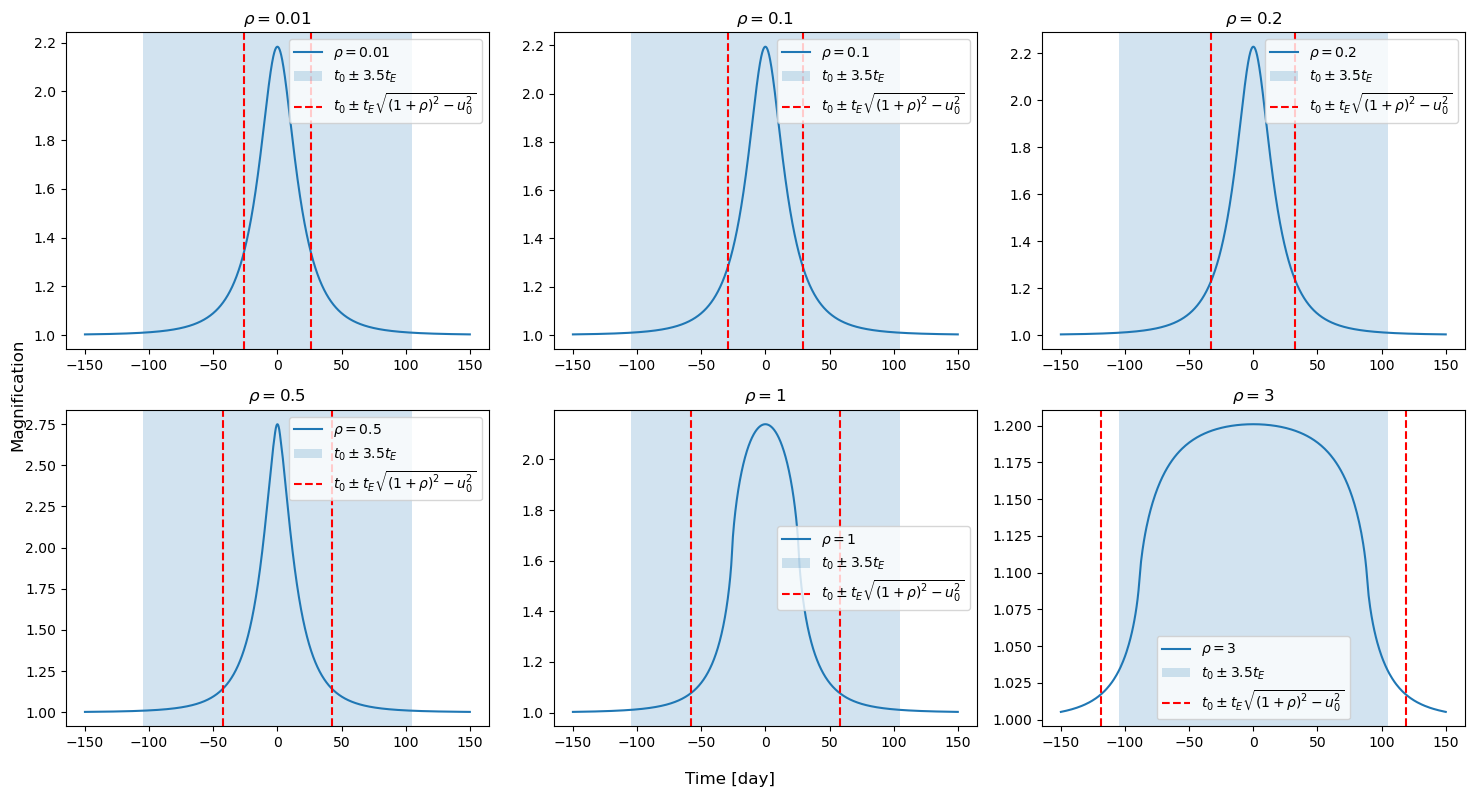

In [46]:
from pyLIMA import event, telescopes
from pyLIMA.simulations import simulator
from pyLIMA.models import FSPLarge_model
simulated_event = event.Event()
simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70

t = np.linspace(-150, 150, 5000)
lightcurve_sim = np.c_[t, np.full_like(t, 19.0), np.full_like(t, 0.000000001)]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time','mag','err_mag'],
    lightcurve_units=['JD','mag','mag'],
    location='Earth'
)
simulated_event.telescopes.append(tel)


# case_name, df_row =  "case2", df_cases.loc["case2"]
# params_list = [0]*12
model = FSPLarge_model.FSPLargemodel(simulated_event, parallax=['None', 0]) 
model.define_model_parameters()


rhos = [0.01, 0.1, 0.2, 0.5, 1, 3]
plt.close("all")
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
axes = axes.flatten()  # para iterar fácil
t0=0
u0=0.5
tE=30 

for i, rho in enumerate(rhos):
    
    ax = axes[i]
    
    # my_own_model2, pyLIMA_parameters = odi_run(
        # i, path_TRILEGAL_set, path_GENULENS_set,
        # savepath, path_ephemerides, path_dataslice, rho
    # )1
    #rho=0.1
    params_list = [t0,u0,tE,rho]
    pyLIMA_parameters = model.compute_pyLIMA_parameters(params_list)
    
    tel = model.event.telescopes[0]#.lightcurve
    
    # pyLIMA_parameters["tE"] = 30
    
    A = model.model_magnification(
        tel,
        pyLIMA_parameters
    )#["photometry"]
    
    t = tel.lightcurve["time"]
    
    u0 = pyLIMA_parameters["u0"]
    t0 = pyLIMA_parameters["t0"]
    tE = pyLIMA_parameters["tE"]
    r  = pyLIMA_parameters["rho"]
    
    # curva
    ax.plot(t, A, label=f"$\\rho={r}$")
    
    # zoom temporal
    # ax.set_xlim(t0 - 5*tE, t0 + 5*tE)
    
    # región t0 ± tE
    ax.axvspan(t0 - 3.5*tE, t0 + 3.5*tE, alpha=0.2, label="$t_0\pm 3.5t_E$")
    
    # bordes fuente finita
    if u0<=1:
        delta_t = tE * np.sqrt((1 + r)**2 - u0**2)
    else:
        delta_t = tE * (1 + r)
    ax.axvline(t0 - delta_t, linestyle="--",color="red", label=r"$t_0\pm t_E\sqrt{(1+\rho)^2-u_0^2}$")
    ax.axvline(t0 + delta_t, linestyle="--",color="red")
    
    ax.set_title(f"$\\rho = {r}$")
    ax.legend()

# etiquetas globales
fig.supxlabel("Time [day]")
fig.supylabel("Magnification")

plt.tight_layout()
plt.savefig("/home/anibal/fig_criterio.png")
plt.show()


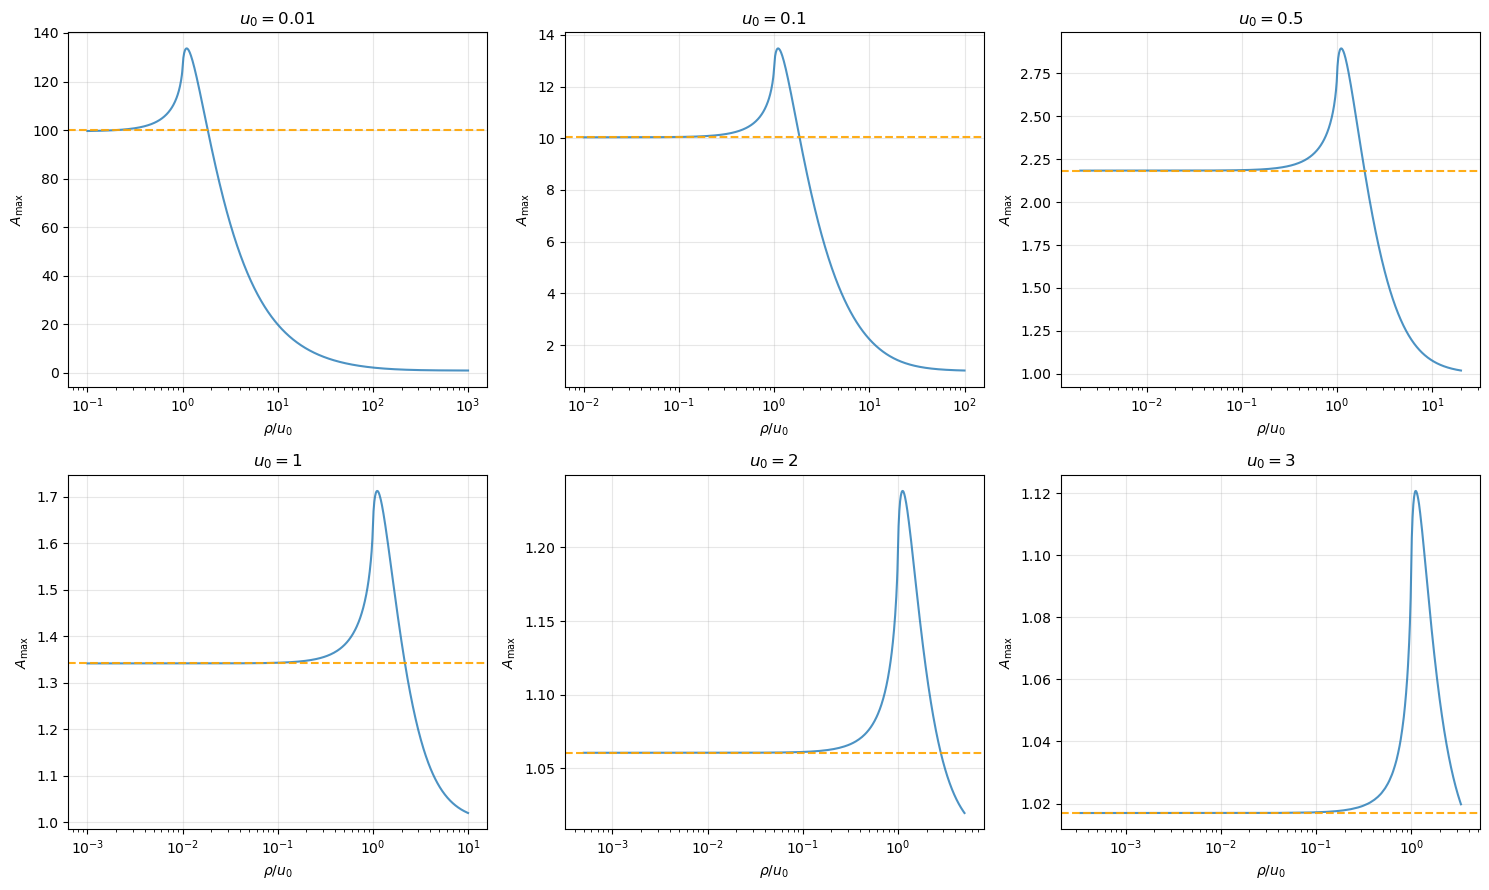

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from pyLIMA import event, telescopes
from pyLIMA.models import FSPLarge_model
def A_pspl(u0):
    return (u0**2+2)/(u0*np.sqrt(u0**2+4))
# ============================================================
# Evento simulado
# ============================================================
simulated_event = event.Event()
simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70

t = np.linspace(-150, 150, 5000)

lightcurve_sim = np.c_[
    t,
    np.full_like(t, 19.0),
    np.full_like(t, 1e-9)
]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time', 'mag', 'err_mag'],
    lightcurve_units=['JD', 'mag', 'mag'],
    location='Earth'
)

simulated_event.telescopes.append(tel)

# ============================================================
# Modelo FSPL
# ============================================================
model = FSPLarge_model.FSPLargemodel(
    simulated_event,
    parallax=['None', 0]
)

model.define_model_parameters()

# ============================================================
# Parámetros
# ============================================================
rhos = np.logspace(-3,1, 1000)

u0_list = [0.01, 0.1, 0.5, 1, 2, 3]

t0 = 0
tE = 30

# ============================================================
# Figura con subplots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes = axes.flatten()

# ============================================================
# Loop sobre u0
# ============================================================
for j, u0 in enumerate(u0_list):

    ax = axes[j]

    A_max = []

    for rho in rhos:

        params_list = [t0, u0, tE, rho]

        pyLIMA_parameters = model.compute_pyLIMA_parameters(
            params_list
        )

        tel = model.event.telescopes[0]

        A = model.model_magnification(
            tel,
            pyLIMA_parameters
        )

        A_max.append(np.max(A))

    # ========================================================
    # Plot
    # ========================================================
    ax.plot(rhos/u0, A_max, alpha=0.8)
    ax.axhline(A_pspl(u0),color="orange",linestyle="dashed",alpha=0.9)
    ax.set_xscale("log")
    # ax.set_yscale("log")

    ax.set_title(rf"$u_0 = {u0}$")

    ax.set_xlabel(r"$\rho/u_0$")
    ax.set_ylabel(r"$A_{\max}$")

    ax.grid(alpha=0.3)

# ============================================================
# Layout
# ============================================================
plt.tight_layout()

plt.show()

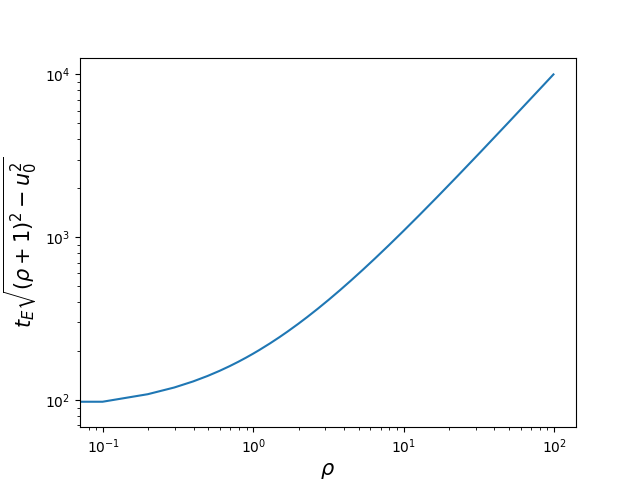

In [38]:
tE = 100
u0=0.5
r = np.linspace(0,99,1000)
delta_t = tE * np.sqrt((1 + r)**2 - u0**2)
plt.close("all")
plt.plot(r,delta_t)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\rho$",fontsize=15)
plt.ylabel(r"$t_E\sqrt{(\rho+1)^2-u_0^2}$",fontsize=15)
plt.show()

In [18]:
path_TRILEGAL_set = f'/home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/chunks_TRILEGAL_GENULENS/TRILEGAL_chunk_{i}.csv'
trilegal_df = pd.read_csv(path_TRILEGAL_set)

def estimate_n_sources(trilegal_df, mag_col, lim_mag, fov_deg2, omega_trilegal_deg2=1.0):
    """
    Estima el número de fuentes observables para un instrumento.

    trilegal_df: catálogo TRILEGAL
    mag_col: banda usada, por ejemplo 'g' o 'W149'
    lim_mag: magnitud límite
    fov_deg2: FOV del instrumento en deg^2
    omega_trilegal_deg2: área representada por el catálogo TRILEGAL
    """
    visible = trilegal_df[trilegal_df[mag_col] < lim_mag]
    surface_density = len(visible) / omega_trilegal_deg2
    n_sources = surface_density * fov_deg2

    return n_sources, surface_density

N_ODI, sigma_ODI = estimate_n_sources(trilegal_df, "g", 21.54, 1.0)
N_CS, sigma_CS = estimate_n_sources(trilegal_df, "g", 18.65, 2.16)
N_ROMAN, sigma_ROMAN = estimate_n_sources(trilegal_df, "W149", 27.6, 0.28)

print("ODI:", N_ODI, "fuentes")
print("CS:", N_CS, "fuentes")
print("Roman:", N_ROMAN, "fuentes")

ODI: 1104.0 fuentes
CS: 1280.88 fuentes
Roman: 2800.0000000000005 fuentes


In [17]:
print(data.files)

['t_odi', 'A_odi', 'flux_odi', 'mag_odi', 't_roman', 'A_roman', 'flux_roman', 'mag_roman', 'mag_err', 't0', 'tE', 'u0', 'rho', 's', 'q', 'alpha', 'piEE', 'piEN']


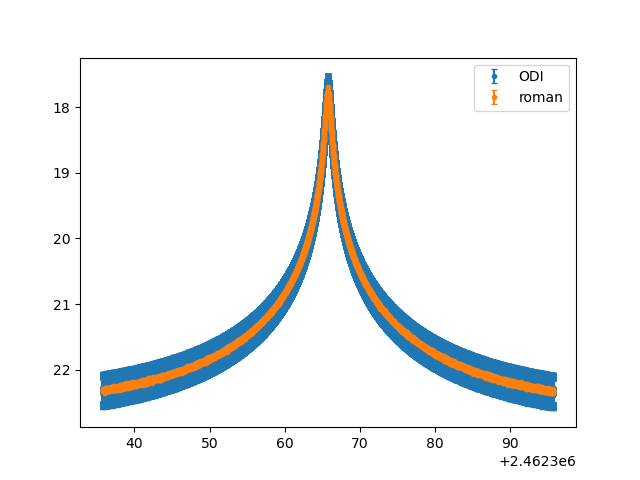

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def add_noise(pyLIMA_telescope, event):
    """
    Add magnitude noise to CS or ODI light curve.
    """

    m = np.array([9,10,11,12,13,14,15,16,17,18,19,20,21,22,23])

    S_N = {
        "ODI": np.array([5228.1,3298.5,2080.8,1312.3,827.1,520.4,326.1,202.2,122.5,70.7,37.5,18,7.9,3.3,1.3]),
        "CS":  np.array([908.5,573,361.2,227.4,142.6,88.7,54.1,31.6,17.1,8.4,3.7,1.6,0.6,0.3,0.1])
    }

    
    # S_N_CS=np.array([908.5,573,361.2,227.4,142.6,88.7,54.1,31.6,17.1,8.4,3.7,1.6,0.6,0.3,0.1])
    # S_N_ODI=np.array([5228.1,3298.5,2080.8,1312.3,827.1,520.4,326.1,202.2,122.5,70.7,37.5,18,7.9,3.3,1.3])

    telescope_name = event.name
    ZP = event.ZP_dict
    #ZP = {'W149': 27.615, 'CS': 27.03, 'ODI': 27.615}

    if telescope_name not in S_N:
        raise ValueError("telescope_name debe ser 'ODI' o 'CS'")

    SN_interp_log = interp1d(
        m,
        np.log10(S_N[telescope_name]),
        kind="linear",
        bounds_error=True
    )

    def delta_m(Signal_to_noise):
        return (2.5 / np.log(10)) / Signal_to_noise

    def SN(mag_value):
        return 10**SN_interp_log(mag_value)

    def sigma_m(mag_value):
        return delta_m(SN(mag_value))

    X = pyLIMA_telescope.lightcurve["time"].value
    flux = pyLIMA_telescope.lightcurve["flux"].value

    ym = mag(ZP[telescope_name], flux)

    err_mag = sigma_m(ym)

    mag_noisy = np.random.normal(
        loc=ym,
        scale=err_mag
    )

    data_tbl = QTable(
        [
            pyLIMA_telescope.lightcurve["err_flux"].value,
            err_mag,
            flux,
            pyLIMA_telescope.lightcurve["inv_err_flux"].value,
            mag_noisy,
            X,
        ],
        names=(
            "err_flux",
            "err_mag",
            "flux",
            "inv_err_flux",
            "mag",
            "time",
        ),
    )
    pyLIMA_telescope.lightcurve = data_tbl

    return pyLIMA_telescope




In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

data = np.load("/home/anibal/test_odi_lightcurves/lightcurve_chunks_joined.npz")

# Magnitudes tabuladas
m = np.array([9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])

# Signal-to-noise para ODI
S_N_ODI = np.array([
    5228.1, 3298.5, 2080.8, 1312.3, 827.1,
    520.4, 326.1, 202.2, 122.5, 70.7,
    37.5, 18.0, 7.9, 3.3, 1.3
])

# Interpolación en log10(S/N), igual que en tu función add_noise
SN_interp_log_ODI = interp1d(
    m,
    np.log10(S_N_ODI),
    kind="linear",
    bounds_error=True
)

def delta_m(signal_to_noise):
    return (2.5 / np.log(10)) / signal_to_noise

def SN_ODI(mag_value):
    return 10**SN_interp_log_ODI(mag_value)

def sigma_m_ODI(mag_value):
    return delta_m(SN_ODI(mag_value))

# Error en magnitud para cada punto ODI
mag_err_odi = sigma_m_ODI(data["mag_odi"])

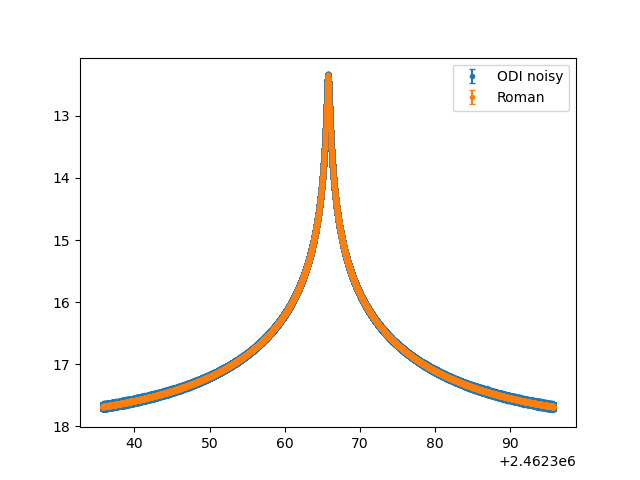

In [13]:
data = np.load("/home/anibal/test_odi_lightcurves/lightcurve_chunks_joined.npz")
%matplotlib widget
# plt.close("all")
# plt.errorbar(data["t_odi"],data["mag_odi"],mag_err_odi,marker=".",linestyle="",capsize=2,label="ODI")
# plt.errorbar(data["t_roman"],data["mag_roman"],data["mag_err"],marker=".",linestyle="",capsize=2,label="roman")
# plt.gca().invert_yaxis()
# plt.legend()
# plt.show()

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

data = np.load("/home/anibal/test_odi_lightcurves/lightcurve_chunks_joined.npz")

# Magnitudes tabuladas
m = np.array([9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])

# Signal-to-noise para ODI
S_N_ODI = np.array([
    5228.1, 3298.5, 2080.8, 1312.3, 827.1,
    520.4, 326.1, 202.2, 122.5, 70.7,
    37.5, 18.0, 7.9, 3.3, 1.3
])

SN_interp_log_ODI = interp1d(
    m,
    np.log10(S_N_ODI),
    kind="linear",
    bounds_error=True
)

def delta_m(signal_to_noise):
    return (2.5 / np.log(10)) / signal_to_noise

def SN_ODI(mag_value):
    return 10**SN_interp_log_ODI(mag_value)

def sigma_m_ODI(mag_value):
    return delta_m(SN_ODI(mag_value))

# Error en magnitud ODI
mag_err_odi = sigma_m_ODI(data["mag_odi"])

# Magnitudes ODI con ruido gaussiano
rng = np.random.default_rng(seed=2026)

mag_odi_noisy = rng.normal(
    loc=data["mag_odi"],
    scale=mag_err_odi
)

%matplotlib widget

plt.close("all")

plt.errorbar(
    data["t_odi"],
    mag_odi_noisy,
    mag_err_odi,
    marker=".",
    linestyle="",
    capsize=2,
    label="ODI noisy"
)

plt.errorbar(data["t_roman"],
    data["mag_roman"]-27.4+27.6,
    data["mag_err"],
    marker=".",
    linestyle="",
    capsize=2,
    label="Roman")

plt.gca().invert_yaxis()
plt.legend()
plt.show()

In [32]:
DS=8000
thetaE=1
((0.5*u.AU*u.rad.to("mas")*u.mas/(DS*u.pc))/(thetaE*u.mas)).decompose()

<Quantity 0.0625>

In [25]:
from astropy import units as u
ratio = (0.5*u.AU/(8*u.kpc)).decompose()*u.rad
print(ratio)
print((ratio/u.mas).decompose())

3.0300855069346e-10 rad
0.06249999999999999
